## Load Imports

### Install required libraries

In [21]:
%pip install pandas seaborn scanpy numpy scikit-misc matplotlib

Note: you may need to restart the kernel to use updated packages.


### Load the imports

In [1]:
import pandas as pd
import seaborn as sns
import os
import scanpy as sc
import numpy as np
import matplotlib.pyplot as plt

## Load the dataset

In [2]:
#Load Data
folder_path = '../data/raw_gene_bc_matrices/hg19' #directory with the '.mtx' file
if not os.path.exists(folder_path):
    print(f'Could not find data in path {folder_path}')
# read in the count matrix into an AnnData (annotated data matrix) object
adata = sc.read_10x_mtx(folder_path, var_names = 'gene_symbols',cache = True)
print(adata)

AnnData object with n_obs × n_vars = 737280 × 32738
    var: 'gene_ids'


## Beginning Quality Control

### Barcode Rank Plot
Reproducing the barcode rank plot seen in [summary](https://cf.10xgenomics.com/samples/cell-exp/1.1.0/pbmc3k/pbmc3k_web_summary.html) provided by 10xgenomics for practice. A barcode rank plot is a comon strategy for cell barcode identification and correction. We are attempting to identify an inflection point (to characterize frequently occuring barcodes from infrequent) as a likely point of discrimination between properly captured cells and empty droplets. Since this is a practice dataset, we already know where this occurs.

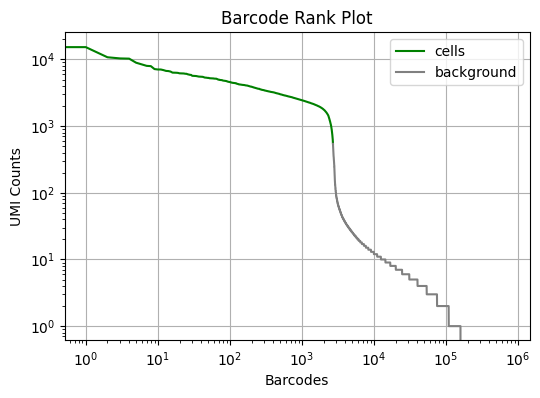

In [3]:
# Sorting UMIs descending order
adata.obs['total_counts'] = adata.X.sum(axis=1).A1 # .A1 flattens it to an array
rank = np.arange(len(adata.obs['total_counts']))
sorted_counts = np.sort(adata.obs['total_counts'])[::-1]
#Plot
plt.figure(figsize=(6,4))
inflection = 2700 #Value given as number of cells from cell ranger summary report (10xgenomics)
plt.loglog(rank[:inflection],sorted_counts[:inflection],color = 'g',label = 'cells')
plt.loglog(rank[inflection:],sorted_counts[inflection:], color = '0.5', label = 'background')
plt.xlabel('Barcodes')
plt.ylabel('UMI Counts')
plt.title('Barcode Rank Plot')
plt.legend()
plt.grid(True)
plt.show()

### Broad Filter and Gene Filter
Remove the background based on observations made in the barcode (knee) plot. Additionally, filter out cells with low complexity (less than 200 unique genes) and filter out genes that are expressed in less than 3 cells.

In [ ]:
#Removing Background
adata = adata[adata.obs.total_counts > sorted_counts[inflection],:]
print(f'Cells remaining after knee-filtering: {adata.n_obs}')
#Filtering cells 
sc.pp.filter_cells(adata, min_genes=200)
#Filtering genes that are statistically insignificant
sc.pp.filter_genes(adata,min_cells=3)
print(f'Genes remaining after filtering: {adata.n_vars}')
print(adata)

Cells remaining after knee-filtering: 2700
Genes remaining after filtering: 13714
AnnData object with n_obs × n_vars = 2700 × 13714
    obs: 'total_counts', 'n_genes'
    var: 'gene_ids', 'n_cells'


c:\Users\m33da\miniconda3\Lib\site-packages\scanpy\preprocessing\_simple.py:161: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs["n_genes"] = number


### Calculating Quality Control Metrics

In [5]:
# mitochondrial genes
adata.var['mt'] = adata.var_names.str.startswith('MT-') # Sticking with the basics for now
# ribosomal genes
#adata.var['ribo'] = adata.var_names.str.startswith(('RPS','RPL'))
# hemoglobin genes
#adata.var['hb'] = adata.var_names.str.startswith('^HB[^(P)]')

# calculate QC metrics
# sc.pp.calculate_qc_metrics(adata,qc_vars=['mt','ribo','hb'], inplace = True, percent_top=None,log1p=True)
sc.pp.calculate_qc_metrics(adata,qc_vars=['mt'], inplace = True, percent_top=None,log1p=True)
print(adata)

AnnData object with n_obs × n_vars = 2700 × 13714
    obs: 'total_counts', 'n_genes', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt'
    var: 'gene_ids', 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'


### Visualizations for QC

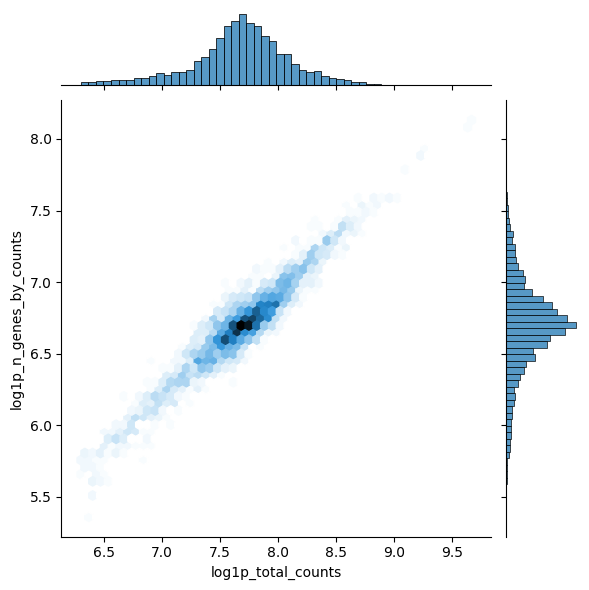

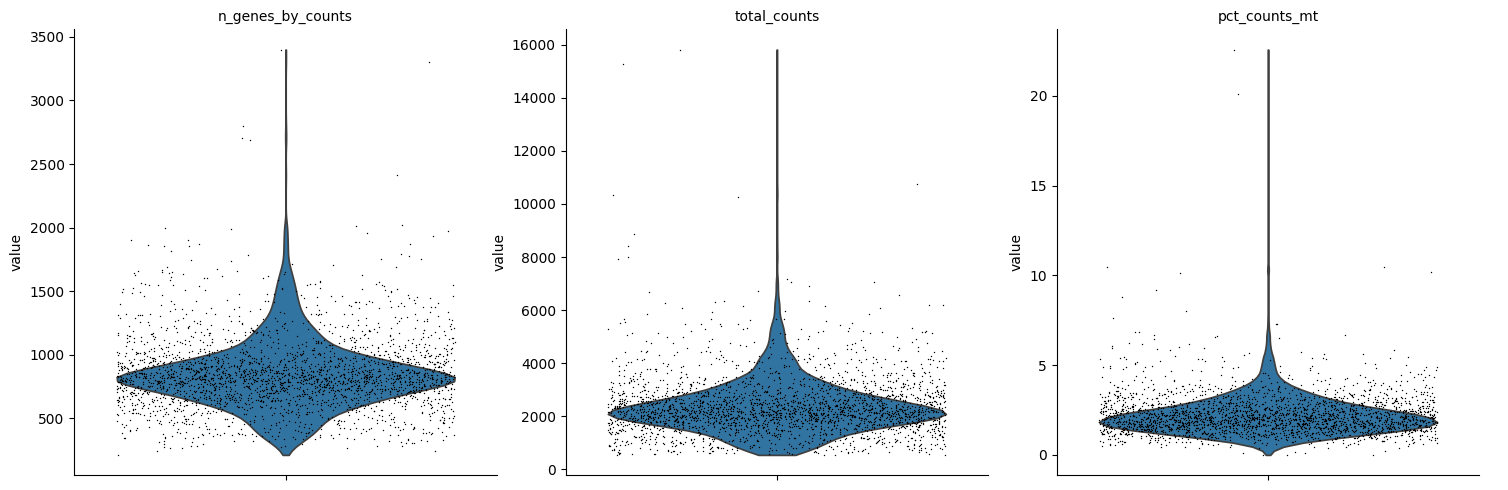

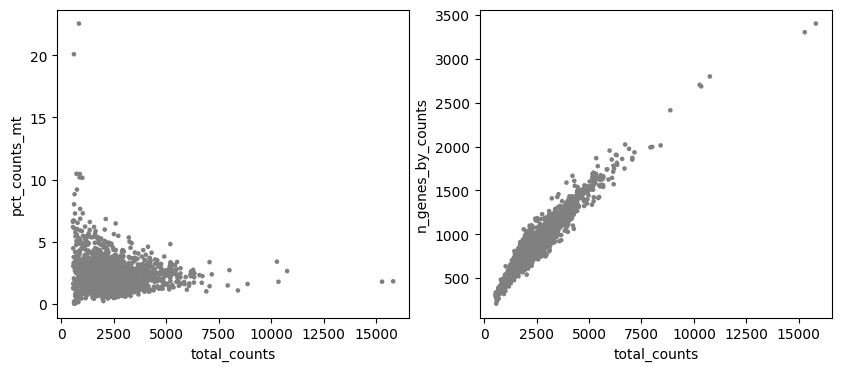

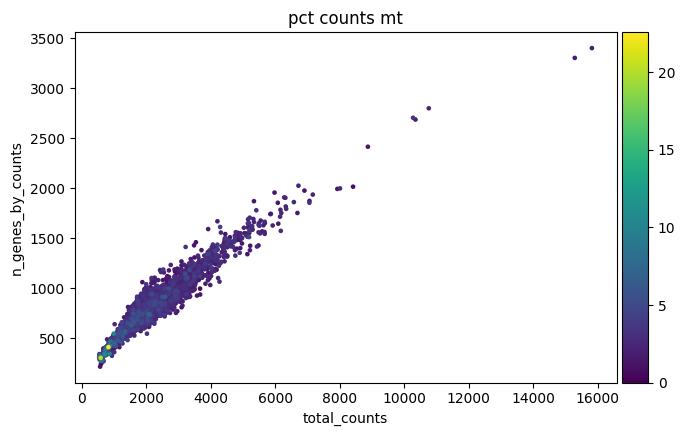

In [6]:
sns.jointplot(data=adata.obs, x= 'log1p_total_counts', y = 'log1p_n_genes_by_counts',kind='hex')

sc.pl.violin(adata,['n_genes_by_counts','total_counts','pct_counts_mt'],jitter=.4,multi_panel=True)

fig,axs = plt.subplots(1,2,figsize = (10,4))
sc.pl.scatter(adata, x='total_counts', y='pct_counts_mt', show = False,ax = axs[0])
sc.pl.scatter(adata, x='total_counts', y='n_genes_by_counts', show = False, ax = axs[1])

sc.pl.scatter(adata, x='total_counts', y='n_genes_by_counts', color='pct_counts_mt', show = False)
plt.show()

### Filtering low quality cells
High mitochondrial content is an indication of dying or stressed cells. To ensure only healthy cells remain, we set a mitocondrial limit of 5%. Observations that contain an unusually high number of genes are often doublets.

In [ ]:
mt_cutoff = 5 # standard for PMBCs
gene_cutoff_low = 200
gene_cutoff_up = 2500 # good starting point for PBMC 3k - possible doublets

adata = adata[(adata.obs.pct_counts_mt < mt_cutoff) & (adata.obs.n_genes_by_counts < gene_cutoff_up) & (adata.obs.n_genes_by_counts > gene_cutoff_low),:].copy()
adata.layers['counts'] = adata.X.copy()
print(f'Final (cell count x gene count): {adata}')

Final (cell count x gene count): AnnData object with n_obs × n_vars = 2638 × 13714
    obs: 'total_counts', 'n_genes', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt'
    var: 'gene_ids', 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    layers: 'counts'


## Normalize and Logarithmize the data
Because some cells are sequenced more deeply than others, we normalize so that for every cell, the total UMI count is 10000 reads per cell. 

In [8]:
sc.pp.normalize_total(adata,target_sum=1e4)
sc.pp.log1p(adata)
print('Normalization and logarithmization complete.')

Normalization and logarithmization complete.


## Identifying and extracting highly-variable genes 
Selecting the genes that will help define biological differences between clusters (those that show the most variance)

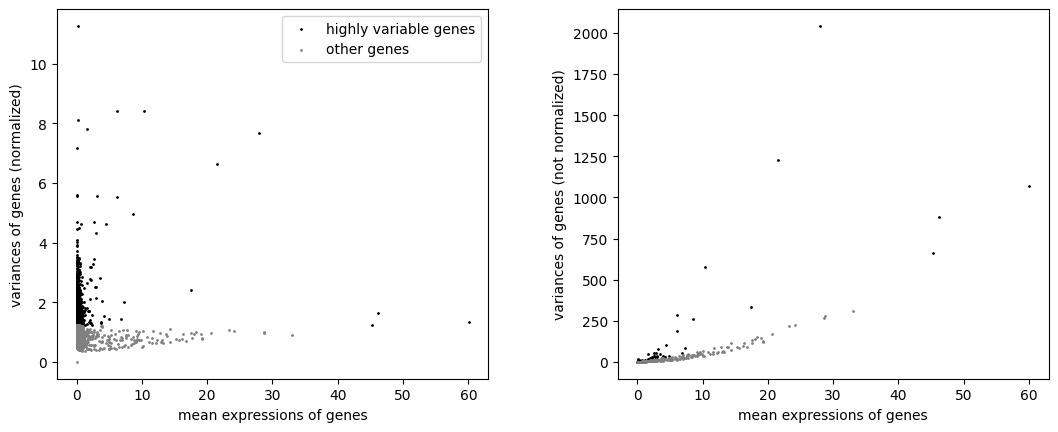

AnnData object with n_obs × n_vars = 2638 × 13714
    obs: 'total_counts', 'n_genes', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt'
    var: 'gene_ids', 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'log1p', 'hvg'
    layers: 'counts'


In [ ]:
sc.pp.highly_variable_genes(adata,layer='counts',n_top_genes=2000,min_mean=.0125,max_mean=3,min_disp=.5,flavor='seurat_v3')
sc.pl.highly_variable_genes(adata)
# store current state for viewing later if needed
adata.raw = adata
plt.show()
print(adata) #observing that the highly-variable-genes detection is stored as an annotation in .var['highly_variable]

## Scaling
Final preparation-ML works best when each feature has a mean of 0 and a standard deviation of 1. This prevents larger features (more expressed genes) from dominanting smaller features (genes with less expression).

In [ ]:
adata.layers['scaled'] = adata.X.toarray()
sc.pp.regress_out(adata,['total_counts','pct_counts_mt'],layer='scaled')
sc.pp.scale(adata,max_value=10,layer='scaled')
print('Scaling complete')
print('\nReady for PCA!!!')